# Тема: Искусственный нейрон и однослойный перцептрон

Искусственный нейрон — это математическая модель биологического нейрона.

Он получает на вход несколько значений x1, x2, ..., xn,
умножает их на соответствующие веса w1, w2, ..., wn,
добавляет смещение (bias) и пропускает результат через функцию активации.

Формула работы нейрона:
y = f(w1*x1 + w2*x2 + b)

где:
  - w — веса,
  - b — смещение (bias),
  - f — функция активации (например, сигмоида, ReLU, tanh).

Однослойный перцептрон — это простейшая нейронная сеть, состоящая из одного слоя искусственных нейронов.

Каждый нейрон принимает на вход несколько признаков и выдает один выход.

Если нейронов несколько, то их выходы формируют вектор — предсказание сети.

Перцептрон способен решать задачи линейной классификации — то есть разделять данные, которые можно отделить прямой или гиперплоскостью.

Однако он не может решить задачи, где классы разделяются нелинейно (например, логическую операцию XOR).

Правило обучения перцептрона:

w = w + η * (y_true - y_pred) * x
где:
  - η — скорость обучения,
  - y_true — истинное значение,
  - y_pred — предсказанное.

Таким образом, перцептрон корректирует веса, если предсказание неверное, постепенно улучшая свою способность различать классы.

In [150]:
import numpy as np
import matplotlib.pyplot as plt

Функции активации

In [151]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def threshold(z):
    return 1 if z >= 0 else 0

def tanh(z):
    posterm, negterm = np.exp(z), np.exp(-z)
    return (posterm - negterm) / (posterm + negterm)

def arctan(z):
    return np.arctan(z)

def neuron_output(X, w, b):
    z = np.dot(X, w) + b
    return z

In [152]:
SIZE = 100
SEED = 45

In [153]:
np.random.seed(SEED)

class_1 = np.random.randn(SIZE, 2) + np.array([-2, -2])
class_2 = np.random.randn(SIZE, 2) + np.array([2, 2])

X = np.vstack((class_1, class_2))
y = np.array([0]*SIZE + [1]*SIZE)

In [154]:
w = np.random.randn(2)
b = 0.0

outputs = sigmoid(neuron_output(X, w, b))

y_pred = (outputs > 0.5).astype(int)

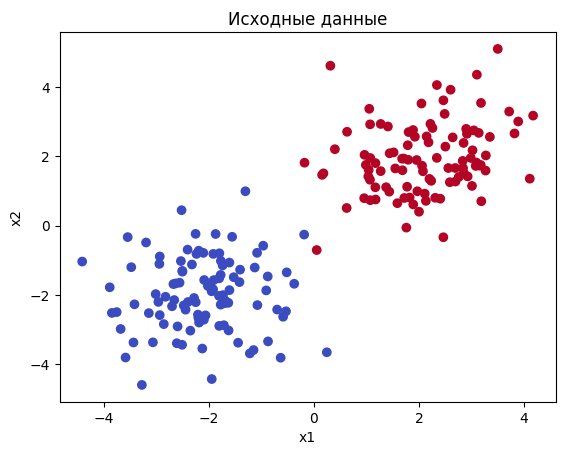

In [155]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm')
plt.title('Исходные данные')
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()

In [156]:
def plot_decision_boundary(w, b, f = lambda x: x, threshold=0.0, ax=None, fname='тождественная'):
    """
    w - веса перцептрона
    b - смещение перцептрона
    f - функция активации
    threshold - порог классификации (значения выше определяются как 1, иначе 0)
    ax - оси графика matplotlib, если заданы, иначе простой вывод через plt.show()
    fname - отображаемое в названии графика имя функции активации
    """
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = f(neuron_output(np.c_[xx.ravel(), yy.ravel()], w, b))
    Z = np.array([1 if z >= threshold else 0 for z in Z])
    Z = Z.reshape(xx.shape)

    if ax is None:
        plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.2, cmap='coolwarm')
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
        plt.title('Граница решений при функции активации\n' + fname)
        plt.xlabel('x1')
        plt.ylabel('x2')
        plt.show()
    else:
        ax.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.2, cmap='coolwarm')
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
        ax.set_title('Граница решений при функции активации\n' + fname)
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')


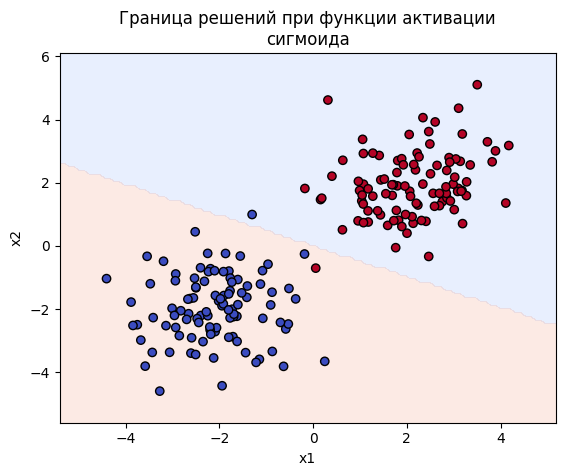

In [157]:
plot_decision_boundary(w, b, sigmoid, 0.5, None, 'сигмоида')

In [158]:
LEARNING_RATE = 0.1
EPOCHS = 10

Метод для обучения однослойного перцептрона на указанном датасете с функцией активации и порогом бинарной классификации

In [159]:
def train_perceptron(w, b, x, y, f=lambda x: x, threshold=0.0):
    """
    w - веса перцептрона
    b - смещение перцептрона
    x - обучающий датасет
    y - предсказываемые бинарные метки (1 и 0)
    f - функция активации перцептрона
    threshold - порог классификации (предсказываемые значения выше него определяются как 1, иначе 0)
    """
    losses = []
    for epoch in range(EPOCHS):
        for i in range(len(x)):
            z = f(np.dot(x[i], w) + b)
            y_pred = 1 if z >= threshold else 0
            error = y[i] - y_pred
            w += LEARNING_RATE * error * X[i]
            b += LEARNING_RATE * error
        
        preds = np.array([1 if f(np.dot(el, w) + b) >= threshold else 0 for el in x])
        acc = (preds == y).mean()
        losses.append(1 - acc)
        # print(f"Эпоха {epoch+1}/{EPOCHS} — точность: {acc:.4f}")
    
    return w, b, losses


Обучаем перцептрон с разными функциями активации 100 раз и выводим графики границ решений для последних.

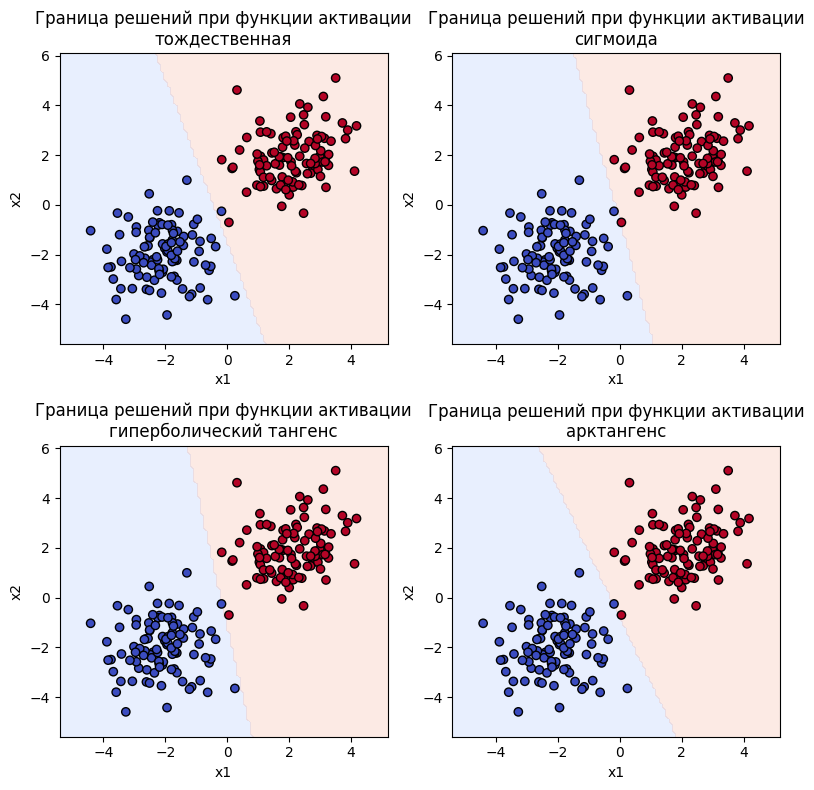

In [160]:
fig, ax = plt.subplots(2, 2, figsize=(8, 8))

losses = []
fnames = ['тождественная', 'сигмоида', 'гиперболический тангенс', 'арктангенс']
for i, (f, thr) in enumerate([(lambda x: x, 0.0), 
                                     (sigmoid, 0.5), 
                                     (tanh, 0.0), 
                                     (arctan, 0.0)]):
    # повторяем эксперимент 100 раз для надёжности сравнения
    # (чтобы быть менее зависимым от случая)
    for _ in range(100):
        w = np.random.randn(2)
        b = 0.0
        w, b, loss = train_perceptron(w, b, X, y, f, thr)

        if len(losses) == i:
            losses.append(loss)
        else:
            losses[i] = [loss[j] + losses[i][j] for j in range(len(losses[i]))]
    else:
        plot_decision_boundary(w, b, f, thr, ax[i//2, i%2], fnames[i])
        # усредняем ошибку
        losses[i] = [losses[i][j] / 100 for j in range(len(losses[i]))]

plt.tight_layout();

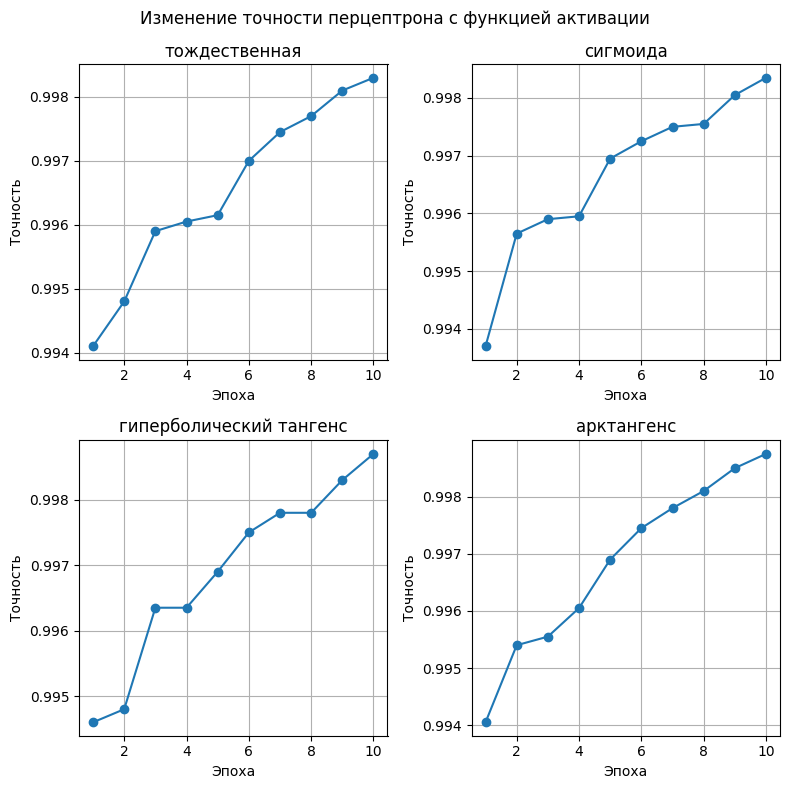

In [161]:
fig, ax = plt.subplots(2, 2, figsize=(8, 8))
plt.suptitle('Изменение точности перцептрона с функцией активации')
for i in range(4):
    ax[i//2, i%2].plot(range(1, EPOCHS + 1), [1 - l for l in losses[i]], marker='o')
    ax[i//2, i%2].set_title(fnames[i])
    ax[i//2, i%2].set_xlabel('Эпоха')
    ax[i//2, i%2].set_ylabel('Точность')
    ax[i//2, i%2].grid(True)
    
plt.tight_layout();

In [ ]:
# точность на последней эпохе
print(*[round(1 - losses[i][-1], 6) for i in range(len(losses))])

0.9983 0.99835 0.9987 0.99875


In [ ]:
# средняя точность за первые 4 эпохи
print(*[round(sum(1 - losses[i][j] for j in range(4)) / 4, 6) for i in range(len(losses))])

0.995212 0.9953 0.995525 0.995262


По графикам точности можно заметить, что в среднем точность на последней эпохе расположена по возрастанию - от тождественной к арктангенсу.

В первые 4 эпохи лучшая средняя точность - с гиперболическим тангенсом.

1. Что делает функция активации в искусственном нейроне? Чем отличается искусственный нейрон от однослойного перцептрона?

    Добавляет нелинейность для возможности моделирования нелинейных зависимостей между данными и таргетом и масштабирует значения в пределах своей области значений.

    Нейрон - модель взвешенного сумматора входных данных и (возможной) функцией активации. Используется для любых задач. 
    Перцептрон - сеть с множеством искусственных нейронов с пороговой функцией активации для решения задачи классификации линейно разделимых данных.

3. Какое правило используется для обучения перцептрона?

    * Вычисление предсказания модели на элементе датасета;
    * Вычисление ошибки как $err = y_i - \hat y_i$, где $y_i$ -истинный таргет, $\hat y_i$ - предсказанное перцептроном значение
    * Прибавление к весам значения $\alpha \cdot err \cdot x_i$ и к смещению значения $\alpha \cdot err$, где $\alpha$ - скорость обучения, $x_i$ - элемент выборки (вектор)
    * Процесс повторяется до сходимости или пока не будет достигнуто заданное число эпох обучения

4. Почему однослойный перцептрон не может решить задачу XOR?

    Функция XOR выглядит так:

    A | B | A ^ B

    0 | 0 | 0

    0 | 1 | 1

    1 | 0 | 1

    1 | 1 | 0

    То есть для обучения перцептрона моделировать эту функцию необходимо выполнение 4-ёх неравенств:

    $b < 0$

    $w_2 + b \ge 0$

    $w_1 + b \ge 0$

    $w_1 + w_2 + b < 0$

    То есть

    $b < 0$

    $w_2 \ge -b > 0$

    $w_1 \ge -b > 0$

    $w_1 + w_2 \ge -2b > 0$

    Но при этом $w_1 + w_2 + b < 0$. При условии $w_1 + w_2 + 2b \ge 0$ выполнение последнего неравества невозможно.

    Следовательно перцептрон не может решить задачу XOR.


5. Что произойдет, если изменить функцию активации с сигмоиды на ReLU?

    Так как из-за сигмоиды часто возникает затухание градиента, замена на функцию ReLU ускорит обучение, т. к. градиент будет стабилен для значений суммы больше нуля.
